In [1]:
# ============================================================
# CUSTOMER CHURN PREDICTION & RISK ANALYTICS SYSTEM
# Advanced Machine Learning Project
# ============================================================

print("Customer Churn Prediction & Risk Analytics System")
print("Machine Learning | Model Comparison | Explainable AI")

Customer Churn Prediction & Risk Analytics System
Machine Learning | Model Comparison | Explainable AI


In [2]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn \
xgboost shap joblib streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 103.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score,
    roc_curve
)

import joblib
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [4]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)

display(df.head())

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Dataset Information")
print("="*60)

print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary")
display(df.describe(include="all").T)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Final Shape:", df.shape)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
Final Shape: (7043, 21)


In [7]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [8]:
# ============================================================
# 🎨 PROJECT VISUALIZATION THEME
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Professional project colors
PRIMARY = "#2563EB"       # Blue
SECONDARY = "#06B6D4"     # Cyan
SUCCESS = "#10B981"       # Green
WARNING = "#F59E0B"       # Orange
DANGER = "#EF4444"        # Red
PURPLE = "#8B5CF6"        # Purple
DARK = "#0F172A"          # Dark Navy
LIGHT = "#F8FAFC"         # Light Background
GRAY = "#64748B"          # Gray

# Model colors
MODEL_COLORS = {
    "Logistic Regression": "#2563EB",
    "KNN": "#8B5CF6",
    "Random Forest": "#10B981",
    "Gradient Boosting": "#F59E0B"
}

# Seaborn theme
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "#F8FAFC"
plt.rcParams["axes.edgecolor"] = "#CBD5E1"
plt.rcParams["axes.labelcolor"] = DARK
plt.rcParams["xtick.color"] = DARK
plt.rcParams["ytick.color"] = DARK
plt.rcParams["text.color"] = DARK
plt.rcParams["axes.titleweight"] = "bold"

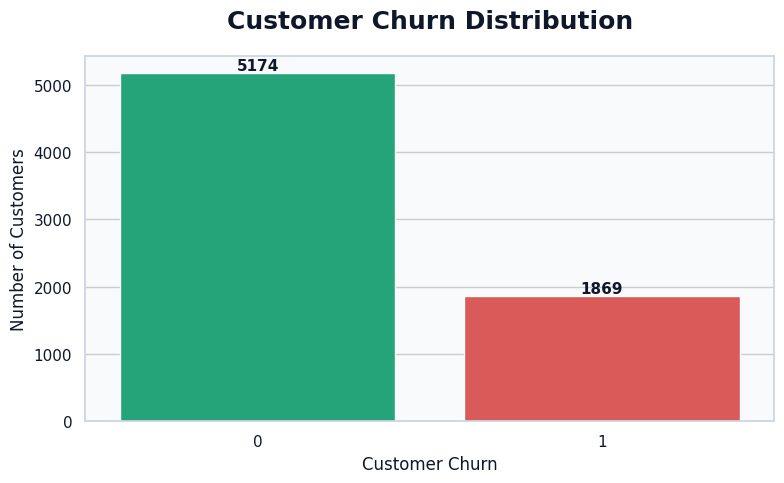

In [9]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette={
        0: SUCCESS,
        1: DANGER
    },
    legend=False
)

plt.title(
    "Customer Churn Distribution",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Customer Churn", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

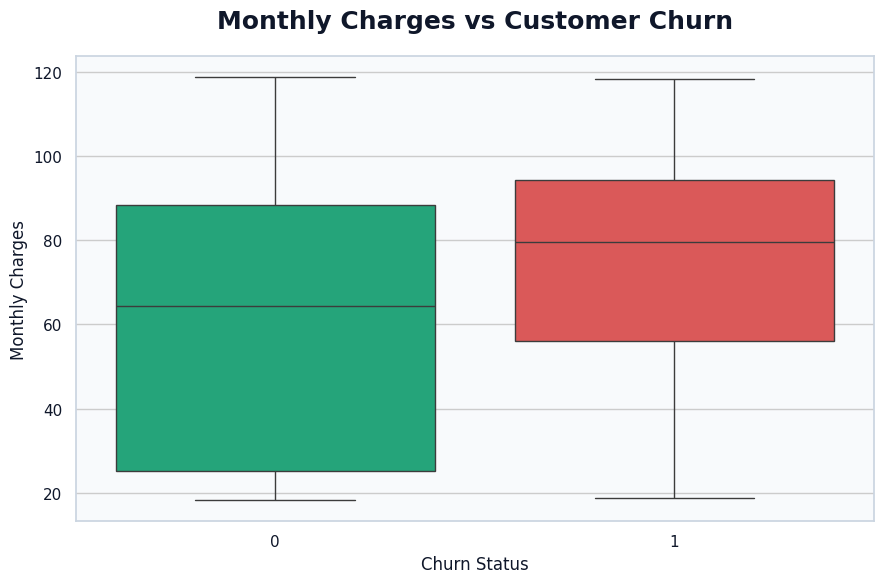

In [10]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette={
        0: SUCCESS,
        1: DANGER
    },
    legend=False
)

plt.title(
    "Monthly Charges vs Customer Churn",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

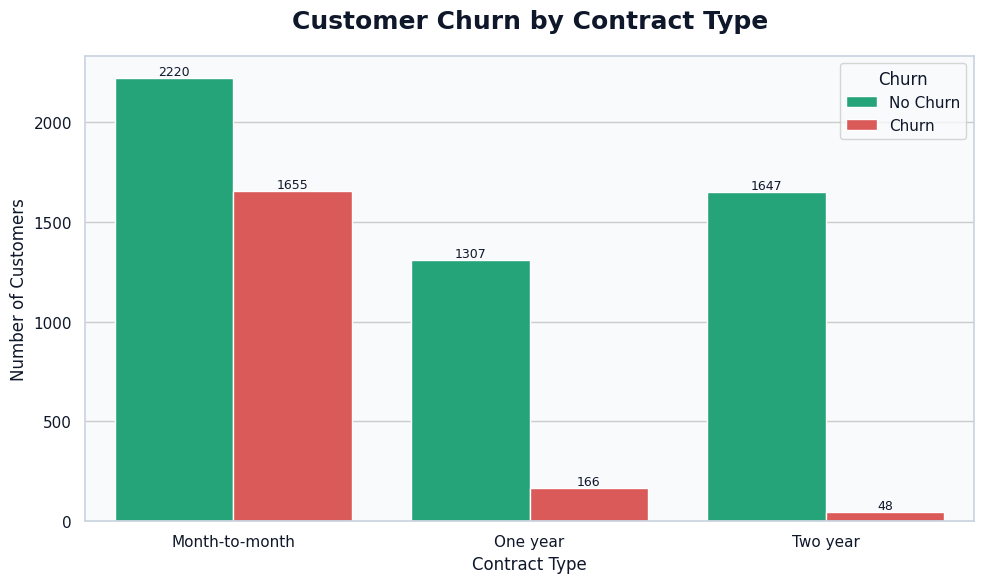

In [11]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette={
        0: SUCCESS,
        1: DANGER
    }
)

plt.title(
    "Customer Churn by Contract Type",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.legend(
    title="Churn",
    labels=["No Churn", "Churn"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=9
    )

plt.tight_layout()
plt.show()

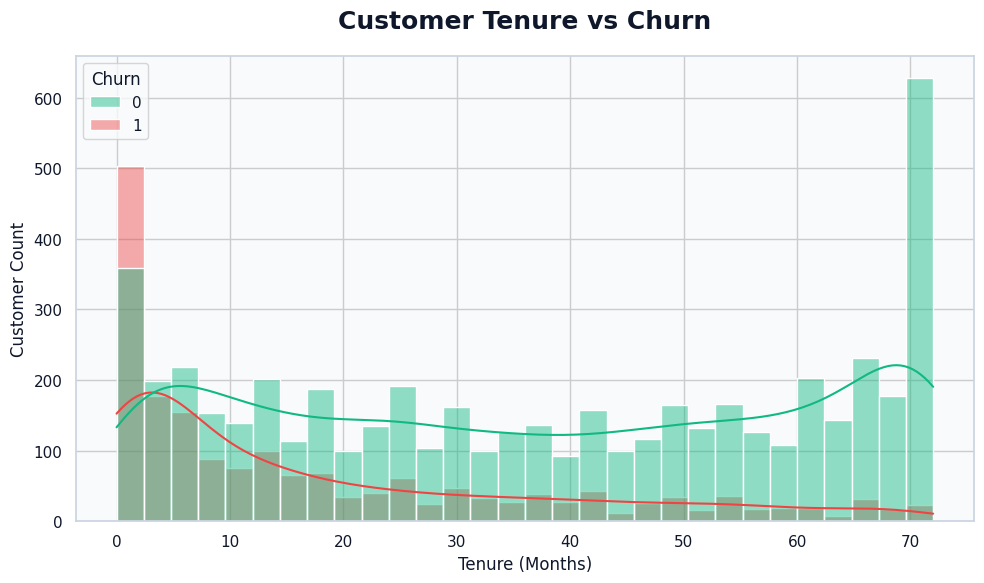

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    kde=True,
    bins=30,
    palette={
        0: SUCCESS,
        1: DANGER
    },
    alpha=0.45
)

plt.title(
    "Customer Tenure vs Churn",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Customer Count")

plt.tight_layout()
plt.show()

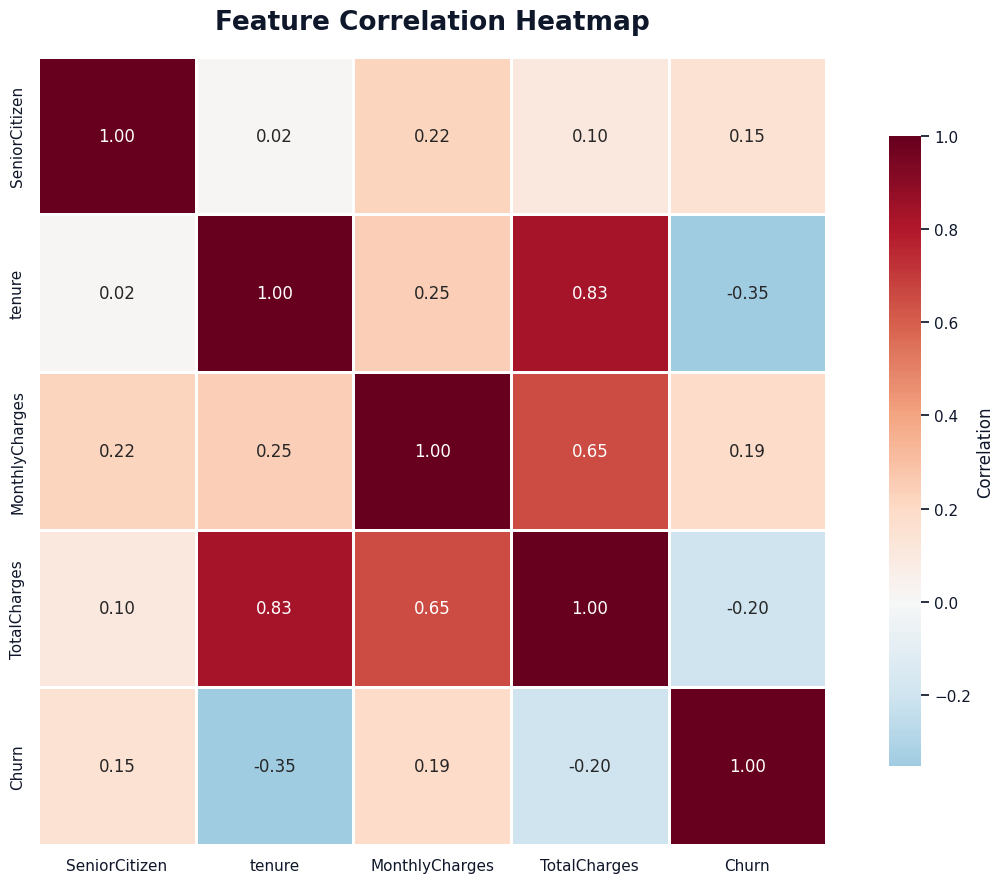

In [13]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(13, 9))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.8,
    linecolor="white",
    square=True,
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlation"
    }
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=19,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

In [16]:
df["AvgMonthlySpend"] = (
    df["TotalCharges"] /
    df["tenure"].replace(0, 1)
)

df["IsNewCustomer"] = (
    df["tenure"] <= 12
).astype(int)

df["HighMonthlyCharge"] = (
    df["MonthlyCharges"] >
    df["MonthlyCharges"].median()
).astype(int)

df["ServiceCount"] = (
    (df["PhoneService"] == "Yes").astype(int) +
    (df["InternetService"] != "No").astype(int) +
    (df["OnlineSecurity"] == "Yes").astype(int) +
    (df["OnlineBackup"] == "Yes").astype(int) +
    (df["DeviceProtection"] == "Yes").astype(int) +
    (df["TechSupport"] == "Yes").astype(int) +
    (df["StreamingTV"] == "Yes").astype(int) +
    (df["StreamingMovies"] == "Yes").astype(int)
)

display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,IsNewCustomer,HighMonthlyCharge,ServiceCount
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000,1,0,2
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,0,55.573529,0,0,4
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,54.075000,1,0,4
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.905556,0,0,4
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,75.825000,1,1,2


In [17]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 24)
Target: (7043,)


In [18]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'IsNewCustomer', 'HighMonthlyCharge', 'ServiceCount']

Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [19]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5634, 24)
Testing Data: (1409, 24)


In [21]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=7
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
}

In [22]:
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[name] = pipeline

    print(f"{name} trained successfully!")

Logistic Regression trained successfully!
KNN trained successfully!
Random Forest trained successfully!
Gradient Boosting trained successfully!


In [23]:
results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_prob
        )
    )

    r2 = r2_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "RMSE": rmse,
        "R²": r2
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,RMSE,R²
3,Gradient Boosting,0.804826,0.678700,0.502674,0.577573,0.846347,0.367823,0.306114
0,Logistic Regression,0.799148,0.654237,0.516043,0.576981,0.841125,0.372298,0.289130
2,Random Forest,0.792761,0.646429,0.483957,0.553517,0.830516,0.376647,0.272424
1,KNN,0.779276,0.589744,0.553476,0.571034,0.805464,0.392533,0.209753


In [24]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=results_df)

https://docs.google.com/spreadsheets/d/1WQdk-p17ZKEmOZM3zTK-fv8PAJzZN0vNSd7iCjzwkSo/edit#gid=0


In [25]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in trained_models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc"
    )

    cv_results.append({
        "Model": name,
        "CV Mean ROC-AUC": scores.mean(),
        "CV Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

display(cv_df)

,Model,CV Mean ROC-AUC,CV Std
0,Logistic Regression,0.845162,0.012489
1,KNN,0.795964,0.011625
2,Random Forest,0.833084,0.014649
3,Gradient Boosting,0.847299,0.009825


In [26]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=cv_df)

https://docs.google.com/spreadsheets/d/1o3UjftzLXOXvR__V8JE5mwnPVSE6sR_8bVeHhlRMruA/edit#gid=0


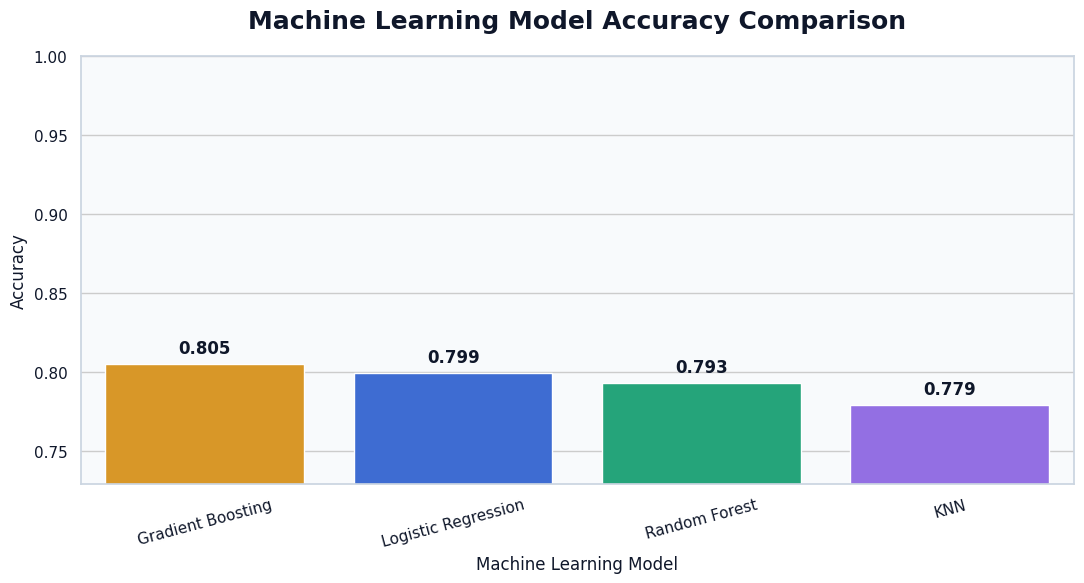

In [27]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette=MODEL_COLORS,
    legend=False
)

plt.title(
    "Machine Learning Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(
    max(0, results_df["Accuracy"].min() - 0.05),
    1
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=5,
        fontweight="bold"
    )

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

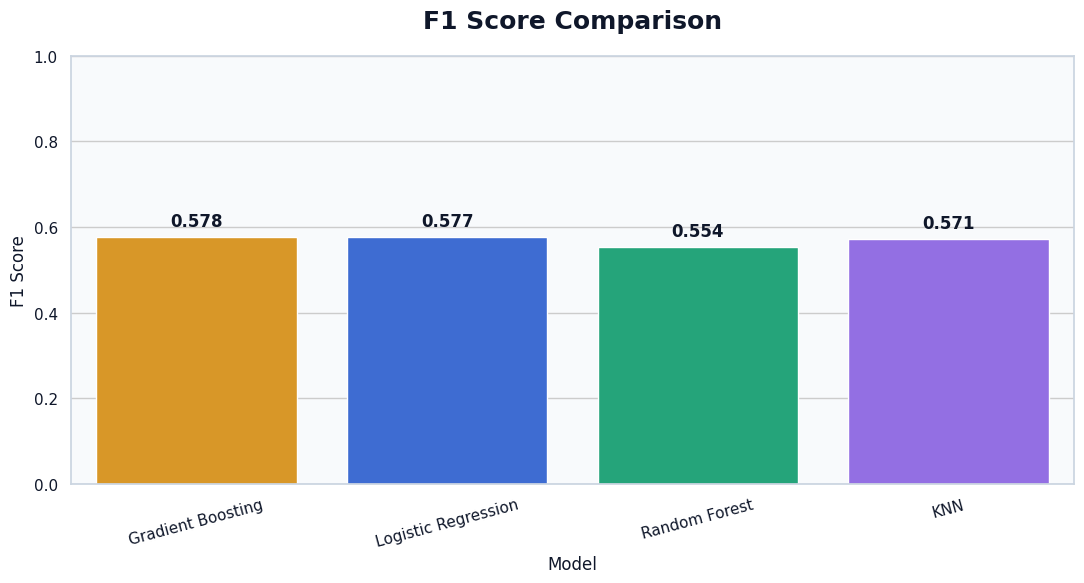

In [28]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score",
    hue="Model",
    palette=MODEL_COLORS,
    legend=False
)

plt.title(
    "F1 Score Comparison",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=5,
        fontweight="bold"
    )

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

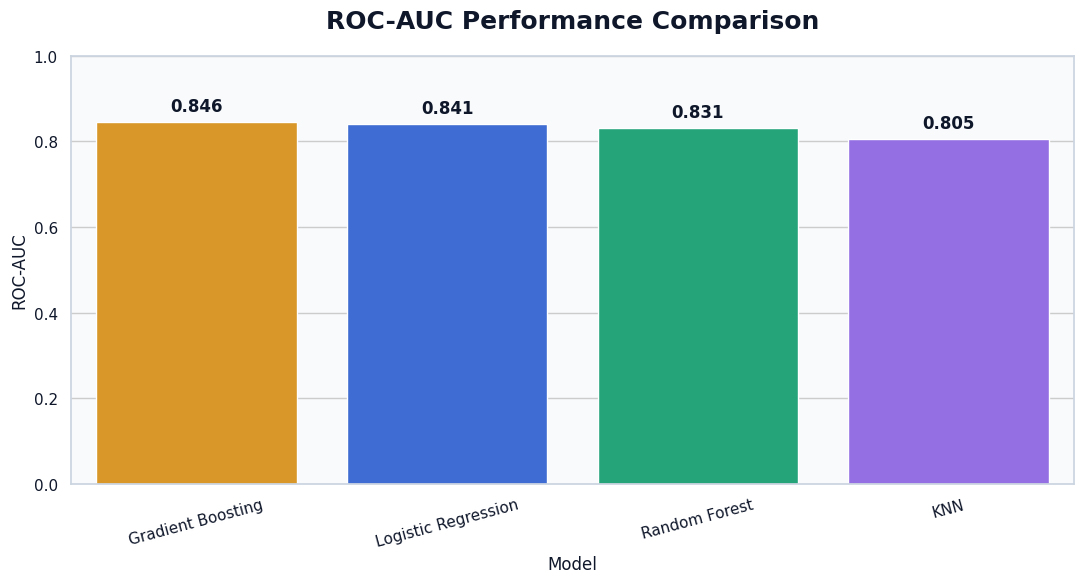

In [29]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=results_df,
    x="Model",
    y="ROC-AUC",
    hue="Model",
    palette=MODEL_COLORS,
    legend=False
)

plt.title(
    "ROC-AUC Performance Comparison",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Model")
plt.ylabel("ROC-AUC")

plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=5,
        fontweight="bold"
    )

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

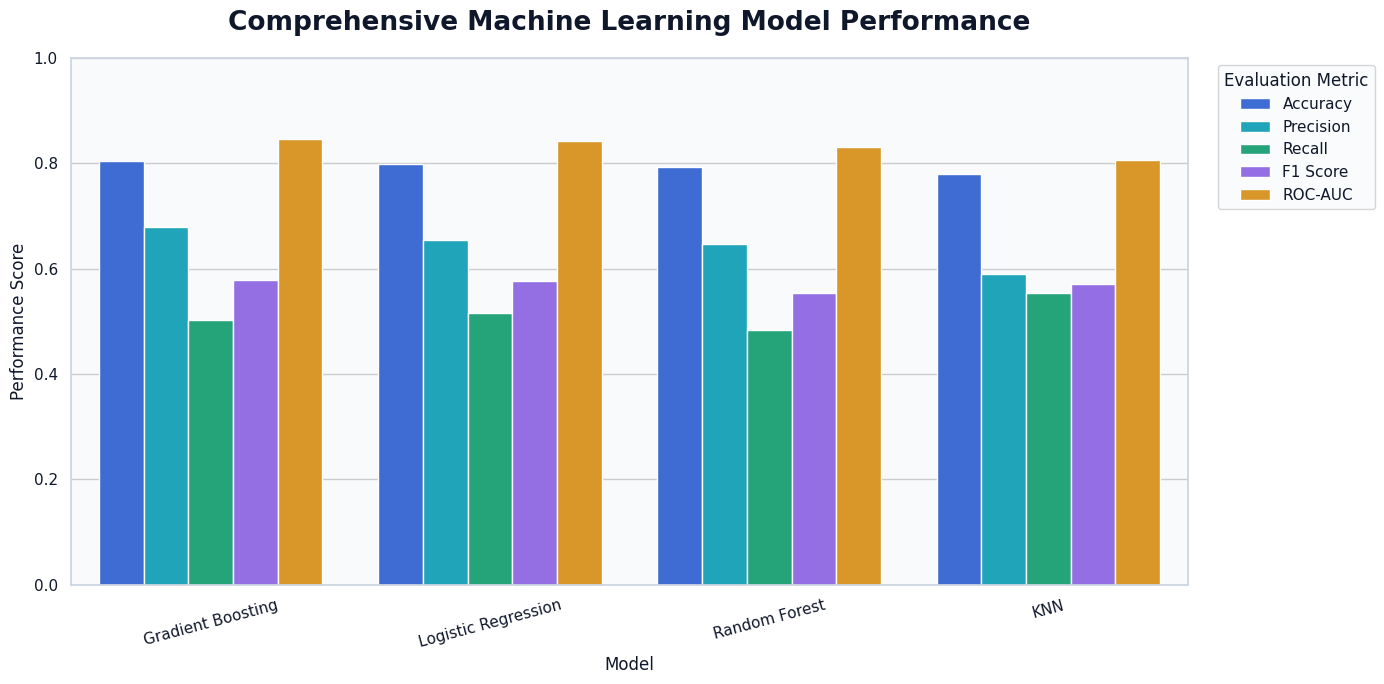

In [30]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

comparison = results_df[
    ["Model"] + metrics
].copy()

comparison_melted = comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=comparison_melted,
    x="Model",
    y="Score",
    hue="Metric",
    palette=[
        PRIMARY,
        SECONDARY,
        SUCCESS,
        PURPLE,
        WARNING
    ]
)

plt.title(
    "Comprehensive Machine Learning Model Performance",
    fontsize=19,
    fontweight="bold",
    pad=20
)

plt.xlabel("Model")
plt.ylabel("Performance Score")

plt.ylim(0, 1)

plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

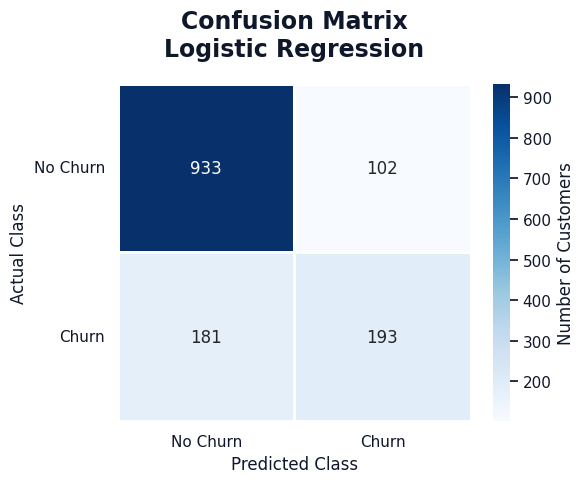

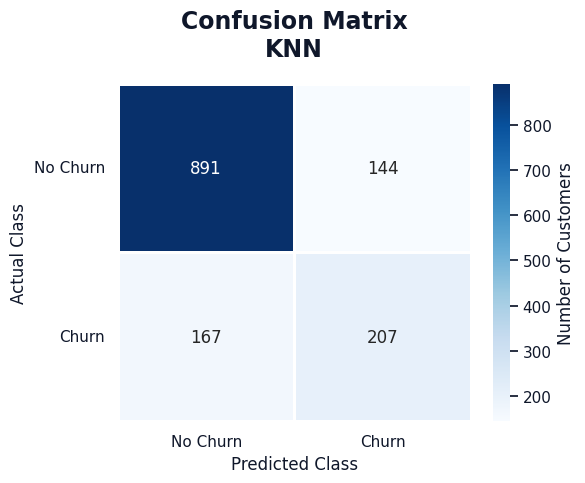

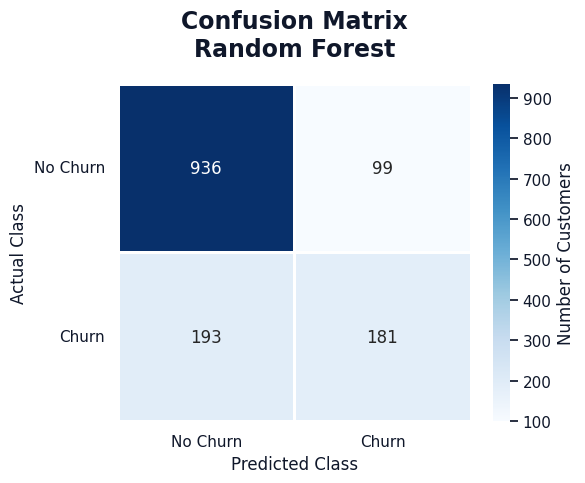

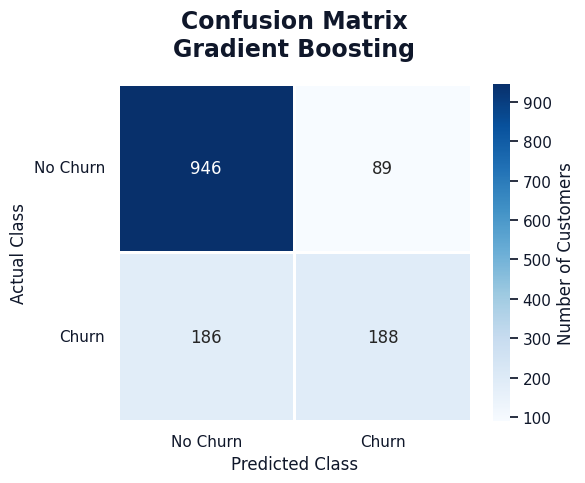

In [31]:
for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=1,
        linecolor="white",
        cbar_kws={
            "label": "Number of Customers"
        }
    )

    plt.title(
        f"Confusion Matrix\n{name}",
        fontsize=17,
        fontweight="bold",
        pad=20
    )

    plt.xlabel(
        "Predicted Class",
        fontsize=12
    )

    plt.ylabel(
        "Actual Class",
        fontsize=12
    )

    plt.xticks(
        [0.5, 1.5],
        ["No Churn", "Churn"]
    )

    plt.yticks(
        [0.5, 1.5],
        ["No Churn", "Churn"],
        rotation=0
    )

    plt.tight_layout()
    plt.show()

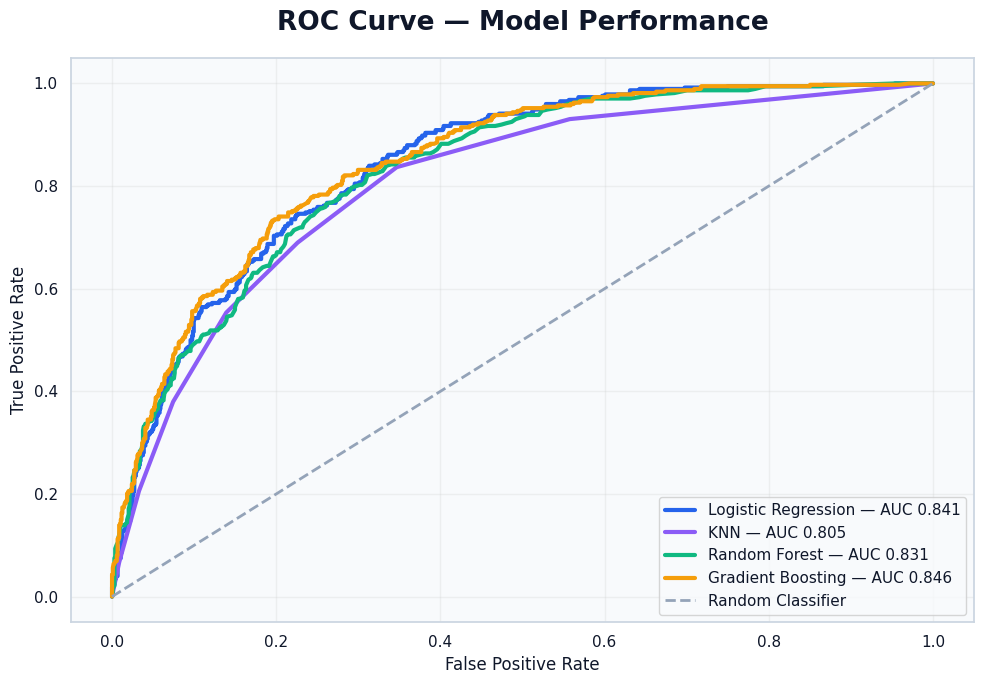

In [32]:
plt.figure(figsize=(10, 7))

for name, model in trained_models.items():

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        color=MODEL_COLORS[name],
        label=f"{name} — AUC {auc:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    color="#94A3B8",
    label="Random Classifier"
)

plt.title(
    "ROC Curve — Model Performance",
    fontsize=19,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.legend(
    loc="lower right",
    frameon=True
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [33]:
best_row = results_df.iloc[0]

best_name = best_row["Model"]
best_accuracy = best_row["Accuracy"]
best_auc = best_row["ROC-AUC"]
best_f1 = best_row["F1 Score"]

print("=" * 60)
print("🏆 BEST MACHINE LEARNING MODEL")
print("=" * 60)

print(f"Model       : {best_name}")
print(f"Accuracy    : {best_accuracy:.2%}")
print(f"F1 Score    : {best_f1:.3f}")
print(f"ROC-AUC     : {best_auc:.3f}")

print("=" * 60)

🏆 BEST MACHINE LEARNING MODEL
Model       : Gradient Boosting
Accuracy    : 80.48%
F1 Score    : 0.578
ROC-AUC     : 0.846


In [35]:
rf_model = trained_models["Random Forest"]

feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = (
    rf_model
    .named_steps["model"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

display(feature_importance)

,Feature,Importance
3,num__TotalCharges,0.072081
1,num__tenure,0.069350
4,num__AvgMonthlySpend,0.060990
2,num__MonthlyCharges,0.058889
5674,cat__Contract_Month-to-month,0.037905
7,num__ServiceCount,0.028696
5,num__IsNewCustomer,0.023943
5656,cat__OnlineSecurity_No,0.022691
5665,cat__TechSupport_No,0.019831
5654,cat__InternetService_Fiber optic,0.018759


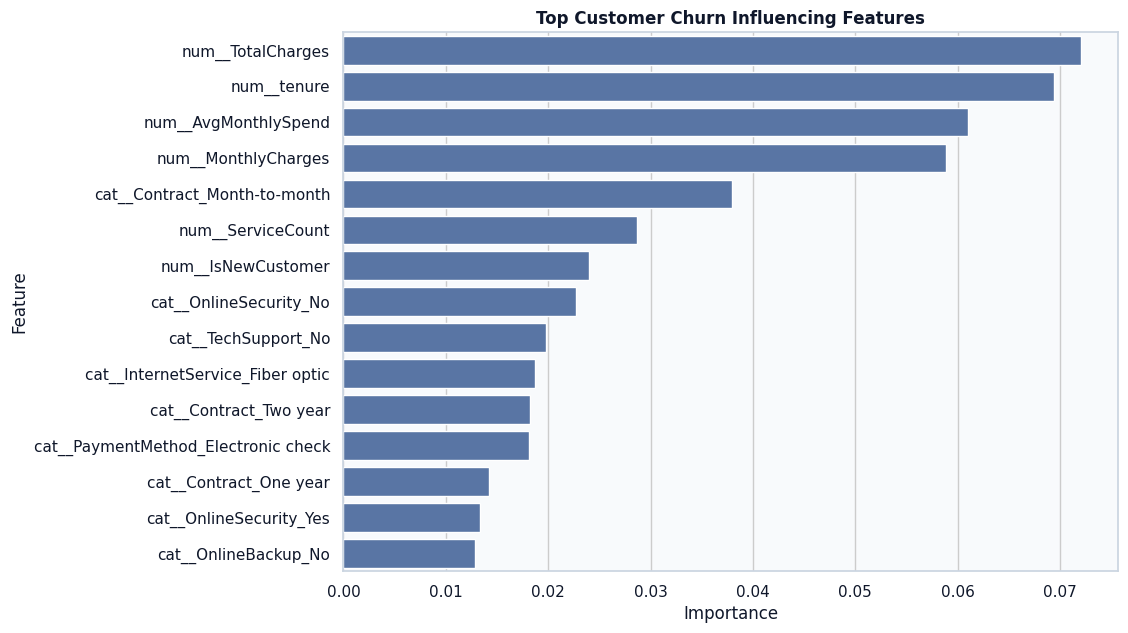

In [36]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Customer Churn Influencing Features"
)

plt.show()

In [39]:
import joblib

In [40]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

In [41]:
import os

print(os.listdir())

['.config', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'sample_data']


In [42]:
import os

print(os.listdir())

['.config', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'sample_data']


In [44]:
joblib.dump(
    best_model,
    "best_churn_model.pkl"
)

print(
    "Best model saved successfully!"
)

Best model saved successfully!


In [45]:
loaded_model = joblib.load(
    "best_churn_model.pkl"
)

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [46]:
from google.colab import files

files.download(
    "best_churn_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
import joblib

model = joblib.load(
    "best_churn_model.pkl"
)

In [48]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load model
model = joblib.load(
    "best_churn_model.pkl"
)

st.set_page_config(
    page_title="Customer Churn Prediction",
    page_icon="📊",
    layout="wide"
)

st.title(
    "📊 Customer Churn Prediction & Risk Analytics"
)

st.write(
    "AI-powered customer churn prediction system"
)

st.sidebar.header(
    "Customer Information"
)

gender = st.sidebar.selectbox(
    "Gender",
    ["Male", "Female"]
)

senior_citizen = st.sidebar.selectbox(
    "Senior Citizen",
    [0, 1]
)

tenure = st.sidebar.number_input(
    "Tenure",
    min_value=0,
    max_value=100,
    value=12
)

monthly_charges = st.sidebar.number_input(
    "Monthly Charges",
    min_value=0.0,
    value=70.0
)

total_charges = st.sidebar.number_input(
    "Total Charges",
    min_value=0.0,
    value=1000.0
)

contract = st.sidebar.selectbox(
    "Contract",
    [
        "Month-to-month",
        "One year",
        "Two year"
    ]
)

internet_service = st.sidebar.selectbox(
    "Internet Service",
    [
        "DSL",
        "Fiber optic",
        "No"
    ]
)

payment_method = st.sidebar.selectbox(
    "Payment Method",
    [
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]
)

2026-08-18 04:56:10.289 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 04:56:10.292 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 04:56:10.618 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-08-18 04:56:10.620 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 04:56:10.622 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 04:56:10.626 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 04:56:10.627 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [49]:
if st.button(
    "🔮 Predict Customer Churn"
):

    input_data = pd.DataFrame({
        "gender": [gender],
        "SeniorCitizen": [senior_citizen],
        "tenure": [tenure],
        "MonthlyCharges": [monthly_charges],
        "TotalCharges": [total_charges],
        "Contract": [contract],
        "InternetService": [internet_service],
        "PaymentMethod": [payment_method]
    })

    prediction = model.predict(
        input_data
    )[0]

    probability = model.predict_proba(
        input_data
    )[0][1]

    st.subheader(
        "Prediction Result"
    )

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Churn Probability",
        f"{probability:.2%}"
    )

    col2.metric(
        "Prediction",
        "CHURN" if prediction == 1
        else "NO CHURN"
    )

    if probability >= 0.70:
        risk = "HIGH RISK"

    elif probability >= 0.40:
        risk = "MEDIUM RISK"

    else:
        risk = "LOW RISK"

    col3.metric(
        "Risk Level",
        risk
    )

2026-08-18 04:56:45.222 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 04:56:45.231 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 04:56:45.235 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 04:56:45.241 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 04:56:45.244 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [50]:
st.markdown("""
<style>

.main {
    background-color: #F8FAFC;
}

h1 {
    color: #0F172A;
    font-weight: 800;
}

h2 {
    color: #2563EB;
    font-weight: 700;
}

h3 {
    color: #0F172A;
}

[data-testid="stMetric"] {
    background-color: white;
    border: 1px solid #E2E8F0;
    padding: 20px;
    border-radius: 15px;
    box-shadow: 0 4px 12px rgba(15, 23, 42, 0.08);
}

.stButton > button {
    background-color: #2563EB;
    color: white;
    border-radius: 10px;
    border: none;
    padding: 10px 25px;
    font-weight: 700;
}

.stButton > button:hover {
    background-color: #1D4ED8;
}

</style>
""", unsafe_allow_html=True)

2026-08-18 04:58:14.143 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 04:58:14.146 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 04:58:14.147 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [52]:
if st.button(
    "🔮 Predict Customer Churn"
):

    input_data = pd.DataFrame({
        "gender": [gender],
        "SeniorCitizen": [senior_citizen],
        "tenure": [tenure],
        "MonthlyCharges": [monthly_charges],
        "TotalCharges": [total_charges],
        "Contract": [contract],
        "InternetService": [internet_service],
        "PaymentMethod": [payment_method]
    })

    prediction = model.predict(
        input_data
    )[0]

    probability = model.predict_proba(
        input_data
    )[0][1]

    st.subheader(
        "Prediction Result"
    )

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Churn Probability",
        f"{probability:.2%}"
    )

    col2.metric(
        "Prediction",
        "CHURN" if prediction == 1
        else "NO CHURN"
    )

    if probability >= 0.70:
        risk = "HIGH RISK"

    elif probability >= 0.40:
        risk = "MEDIUM RISK"

    else:
        risk = "LOW RISK"

    col3.metric(
        "Risk Level",
        risk
    )

2026-08-18 05:02:01.480 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:02:01.480 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:02:01.486 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:02:01.490 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:02:01.492 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [54]:
if st.button("🔮 Predict Customer Churn"):

    # Prediction
    prediction = model.predict(input_data)[0]

    # Churn probability
    probability = float(
        model.predict_proba(input_data)[0][1]
    )

    # Stay probability
    stay_probability = 1.0 - probability

    # Display result
    st.subheader("📊 Customer Churn Probability")

    # Create chart
    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        ["Stay", "Churn"],
        [stay_probability, probability]
    )

    # Y-axis
    ax.set_ylim(0, 1)

    # Labels
    ax.set_ylabel("Probability")
    ax.set_title(
        "Customer Churn Probability",
        fontsize=16,
        fontweight="bold"
    )

    # Display percentage above bars
    for bar, value in zip(
        bars,
        [stay_probability, probability]
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.02,
            f"{value:.1%}",
            ha="center",
            fontweight="bold"
        )

    plt.tight_layout()

    # Show chart in Streamlit
    st.pyplot(fig)

2026-08-18 05:03:39.823 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:03:39.824 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:03:39.828 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:03:39.828 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:03:39.829 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [57]:
print("MODEL FEATURES:")
print(X.columns.tolist())

print("\nNUMBER OF FEATURES:")
print(len(X.columns))

MODEL FEATURES:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'IsNewCustomer', 'HighMonthlyCharge', 'ServiceCount']

NUMBER OF FEATURES:
24


In [58]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Load your saved best model
model = joblib.load("best_churn_model.pkl")

st.title("📊 Customer Churn Prediction System")

# -----------------------------
# CUSTOMER INPUTS
# -----------------------------

gender = st.selectbox(
    "Gender",
    ["Male", "Female"]
)

senior_citizen = st.selectbox(
    "Senior Citizen",
    [0, 1]
)

partner = st.selectbox(
    "Partner",
    ["Yes", "No"]
)

dependents = st.selectbox(
    "Dependents",
    ["Yes", "No"]
)

tenure = st.number_input(
    "Tenure (Months)",
    min_value=0,
    max_value=100,
    value=12
)

phone_service = st.selectbox(
    "Phone Service",
    ["Yes", "No"]
)

internet_service = st.selectbox(
    "Internet Service",
    ["DSL", "Fiber optic", "No"]
)

contract = st.selectbox(
    "Contract",
    ["Month-to-month", "One year", "Two year"]
)

payment_method = st.selectbox(
    "Payment Method",
    [
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]
)

monthly_charges = st.number_input(
    "Monthly Charges",
    min_value=0.0,
    value=70.0
)

total_charges = st.number_input(
    "Total Charges",
    min_value=0.0,
    value=1000.0
)

2026-08-18 05:10:18.669 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:10:18.671 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:10:18.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:10:18.677 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:10:18.679 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:10:18.682 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:10:18.684 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:10:18.686 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [59]:
# -----------------------------
# CREATE INPUT DATA
# -----------------------------

input_data = pd.DataFrame({
    "gender": [gender],
    "SeniorCitizen": [senior_citizen],
    "Partner": [partner],
    "Dependents": [dependents],
    "tenure": [tenure],
    "PhoneService": [phone_service],
    "InternetService": [internet_service],
    "Contract": [contract],
    "PaymentMethod": [payment_method],
    "MonthlyCharges": [monthly_charges],
    "TotalCharges": [total_charges]
})

In [60]:
st.write("Customer Input:")
st.dataframe(input_data)

2026-08-18 05:10:49.135 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:10:49.137 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:10:49.139 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:10:49.215 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:10:49.216 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:10:49.217 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:10:49.218 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [61]:
print(X.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'IsNewCustomer', 'HighMonthlyCharge', 'ServiceCount']


In [62]:
# ============================================================
# PREDICT CUSTOMER CHURN
# ============================================================

if st.button(
    "🔮 PREDICT CUSTOMER CHURN",
    use_container_width=True
):

    # ----------------------------------------
    # Prediction
    # ----------------------------------------

    prediction = model.predict(input_data)[0]

    probability = float(
        model.predict_proba(input_data)[0][1]
    )

    stay_probability = 1.0 - probability

    # ----------------------------------------
    # Risk Level
    # ----------------------------------------

    if probability >= 0.70:

        risk_level = "🔴 HIGH RISK"
        risk_message = "Immediate retention action recommended."

    elif probability >= 0.40:

        risk_level = "🟡 MEDIUM RISK"
        risk_message = "Customer should be monitored closely."

    else:

        risk_level = "🟢 LOW RISK"
        risk_message = "Customer currently appears relatively stable."

    # ========================================================
    # RESULT HEADER
    # ========================================================

    st.markdown("---")

    st.subheader("📊 Prediction Result")

    result_col1, result_col2, result_col3 = st.columns(3)

    with result_col1:

        st.metric(
            "Churn Probability",
            f"{probability:.1%}"
        )

    with result_col2:

        prediction_text = (
            "WILL CHURN"
            if prediction == 1
            else "WILL STAY"
        )

        st.metric(
            "Prediction",
            prediction_text
        )

    with result_col3:

        st.metric(
            "Risk Level",
            risk_level
        )

    st.info(risk_message)

    # ========================================================
    # PROBABILITY CHART
    # ========================================================

    st.subheader(
        "📈 Customer Churn Probability"
    )

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    categories = [
        "Stay",
        "Churn"
    ]

    probabilities = [
        stay_probability,
        probability
    ]

    bars = ax.bar(
        categories,
        probabilities,
        width=0.55
    )

    ax.set_ylim(
        0,
        1
    )

    ax.set_ylabel(
        "Probability"
    )

    ax.set_xlabel(
        "Customer Status"
    )

    ax.set_title(
        "Stay vs Churn Probability",
        fontsize=16,
        fontweight="bold"
    )

    # Add percentage labels
    for bar, value in zip(
        bars,
        probabilities
    ):

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,

            value + 0.03,

            f"{value:.1%}",

            ha="center",
            va="bottom",

            fontsize=13,
            fontweight="bold"
        )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()

    st.pyplot(
        fig,
        use_container_width=True
    )

    # ========================================================
    # RETENTION RECOMMENDATION
    # ========================================================

    st.subheader(
        "💡 Retention Recommendation"
    )

    if probability >= 0.70:

        st.error(
            "🚨 HIGH CHURN RISK"
        )

        st.markdown("""
        ### Recommended Immediate Actions

        - 📞 Contact the customer proactively
        - 🎁 Provide a personalized retention offer
        - 💳 Consider a suitable contract upgrade incentive
        - 🛠️ Review service/support issues
        - 💰 Evaluate pricing concerns
        - ⭐ Provide loyalty benefits
        """)

    elif probability >= 0.40:

        st.warning(
            "⚠️ MEDIUM CHURN RISK"
        )

        st.markdown("""
        ### Recommended Actions

        - 📊 Monitor customer engagement
        - 📩 Send a personalized offer
        - ⭐ Provide loyalty benefits
        - 🛠️ Check service satisfaction
        - 📞 Follow up with the customer
        """)

    else:

        st.success(
            "✅ LOW CHURN RISK"
        )

        st.markdown("""
        ### Recommended Actions

        - ⭐ Continue customer engagement
        - 🎁 Consider loyalty rewards
        - 📩 Maintain regular communication
        - 📊 Monitor future customer activity
        """)

    # ========================================================
    # CUSTOMER SUMMARY
    # ========================================================

    st.subheader(
        "👤 Customer Analysis Summary"
    )

    summary_col1, summary_col2 = st.columns(2)

    with summary_col1:

        st.write(
            f"**Tenure:** {tenure} months"
        )

        st.write(
            f"**Monthly Charges:** ${monthly_charges:.2f}"
        )

        st.write(
            f"**Contract:** {contract}"
        )

    with summary_col2:

        st.write(
            f"**Internet Service:** {internet_service}"
        )

        st.write(
            f"**Payment Method:** {payment_method}"
        )

        st.write(
            f"**Services Used:** {service_count}"
        )

2026-08-18 05:15:38.755 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:15:38.763 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:15:38.766 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:15:38.771 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:15:38.773 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [64]:
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[name] = pipeline

    print(f"✅ {name} trained successfully")

✅ Logistic Regression trained successfully
✅ KNN trained successfully
✅ Random Forest trained successfully
✅ Gradient Boosting trained successfully


In [65]:
# ============================================================
# MODEL EVALUATION & COMPARISON
# ============================================================

results = []

for name, model in trained_models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Prediction probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Evaluation metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    # RMSE of predicted churn probability
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_prob
        )
    )

    # R² of predicted churn probability
    r2 = r2_score(
        y_test,
        y_prob
    )

    # Store results
    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": roc_auc,

        "RMSE": rmse,

        "R²": r2
    })


# ============================================================
# CREATE DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)


# ============================================================
# SORT MODELS
# ============================================================

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("🏆 MODEL COMPARISON RESULTS")
print("=" * 80)

display(results_df)

🏆 MODEL COMPARISON RESULTS


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,RMSE,R²
0,Gradient Boosting,0.804826,0.678700,0.502674,0.577573,0.846347,0.367823,0.306114
1,Logistic Regression,0.799148,0.654237,0.516043,0.576981,0.841125,0.372298,0.289130
2,Random Forest,0.792761,0.646429,0.483957,0.553517,0.830516,0.376647,0.272424
3,KNN,0.779276,0.589744,0.553476,0.571034,0.805464,0.392533,0.209753


In [66]:
# ============================================================
# SAVE MODEL COMPARISON
# ============================================================

results_df.to_csv(
    "model_comparison.csv",
    index=False
)

print("✅ model_comparison.csv created successfully!")

✅ model_comparison.csv created successfully!


In [67]:
import os

print(
    "File exists:",
    os.path.exists("model_comparison.csv")
)

File exists: True


In [68]:
print(
    os.listdir()
)

['.config', 'best_churn_model.pkl', 'model_comparison.csv', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'sample_data']


In [69]:
# ============================================================
# SELECT BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("=" * 60)
print("🏆 BEST MODEL SELECTED")
print("=" * 60)

print("Model:", best_model_name)
print(
    "Accuracy:",
    f"{results_df.iloc[0]['Accuracy']:.2%}"
)

print(
    "F1 Score:",
    f"{results_df.iloc[0]['F1 Score']:.3f}"
)

print(
    "ROC-AUC:",
    f"{results_df.iloc[0]['ROC-AUC']:.3f}"
)

🏆 BEST MODEL SELECTED
Model: Gradient Boosting
Accuracy: 80.48%
F1 Score: 0.578
ROC-AUC: 0.846


In [70]:
import joblib

joblib.dump(
    best_model,
    "best_churn_model.pkl"
)

print("✅ Best model saved successfully!")

✅ Best model saved successfully!


In [71]:
from google.colab import files

files.download(
    "best_churn_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
files.download(
    "model_comparison.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
results_df = pd.read_csv(
    "model_comparison.csv"
)

st.subheader(
    "🤖 Machine Learning Model Comparison"
)

st.dataframe(
    results_df,
    use_container_width=True
)

2026-08-18 05:21:30.988 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:21:30.991 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:21:30.993 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:21:30.997 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-18 05:21:31.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:21:31.008 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:21:31.009 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [74]:
st.dataframe(
    results_df.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "RMSE": "{:.3f}",
        "R²": "{:.3f}"
    }),
    use_container_width=True
)

2026-08-18 05:21:44.259 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-18 05:21:44.260 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:21:44.279 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:21:44.280 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:21:44.284 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-18 05:21:44.286 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()